# FEDERATED UMAP + DIFFERENTIAL PRIVACY

## Loading libraries

In [1]:
import os
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedShuffleSplit

import umap

RANDOM_STATE = 23
rng = np.random.RandomState(RANDOM_STATE)

## DP helpers and privacy accountant

In [2]:
class PrivacyAccountant:
    def __init__(self, total_epsilon, total_delta):
        self.total_epsilon = float(total_epsilon)
        self.total_delta = float(total_delta)
        self.spent_epsilon = 0.0
        self.spent_delta = 0.0
        self.history = []

    def remaining(self):
        return (self.total_epsilon - self.spent_epsilon,
                self.total_delta - self.spent_delta)

    def charge(self, label, eps, delta, sensitivity, sigma):
        if self.spent_epsilon + eps > self.total_epsilon + 1e-9:
            raise RuntimeError(f'Privacy budget (epsilon) exceeded at "{label}"')
        if self.spent_delta + delta > self.total_delta + 1e-12:
            raise RuntimeError(f'Privacy budget (delta) exceeded at "{label}"')
        self.spent_epsilon += eps
        self.spent_delta += delta
        self.history.append((label, eps, delta, float(sigma), float(sensitivity)))

    def report(self):
        print(f'Privacy budget: epsilon_total = {self.total_epsilon}, '
              f'delta_total = {self.total_delta}')
        print(f'Spent: epsilon = {self.spent_epsilon:.4f}, '
              f'delta = {self.spent_delta:.2e}')
        print('-' * 78)
        print(f'{"query":<32}  {"eps":>6}  {"delta":>9}  {"Delta":>10}  {"sigma":>10}')
        for label, eps, delta, sigma, sens in self.history:
            print(f'{label:<32}  {eps:>6.3f}  {delta:>9.1e}  {sens:>10.3f}  {sigma:>10.4f}')


def gaussian_sigma(sensitivity, eps, delta):
    return sensitivity * math.sqrt(2.0 * math.log(1.25 / delta)) / eps


def gaussian_mechanism(value, sensitivity, eps, delta, accountant, label, rng):
    sigma = gaussian_sigma(sensitivity, eps, delta)
    accountant.charge(label, eps, delta, sensitivity, sigma)
    return np.asarray(value) + rng.normal(0.0, sigma, size=np.asarray(value).shape)


def clip(X, lo, hi):
    return np.minimum(np.maximum(X, lo), hi)


def mean_centroid(group):
    return np.mean(group, axis=0)


def cluster_radius_for_centroid(points_2d, centroid, density_th, percent_th, n_class):
    distances = np.linalg.norm(points_2d - centroid, axis=1)
    rad = 1
    rad_def = rad
    percent = 0.0
    density = float('inf')
    while not (percent >= percent_th and density <= density_th):
        rad_def = rad
        rad += 1
        n_inside = int(np.sum(distances <= rad))
        area = math.pi * rad ** 2
        density = n_inside / area
        percent = n_inside / max(n_class, 1)
        if rad > 200:
            break
    return rad_def

## Privacy budget allocation and clipping bounds

In [3]:
TOTAL_EPSILON = 10.0        # loose-but-meaningful DP budget
TOTAL_DELTA = 1e-5

EPS = {
    'std_sum':       1.0,
    'std_sum_sq':    3.0,
    'centroids':     2.0,    # 2 classes -> 1.0 each
    'radii':         1.5,    # 2 classes -> 0.75 each
    'epsilons':      1.5,
    'minmax':        1.0,    # 0.5 each
}
assert abs(sum(EPS.values()) - TOTAL_EPSILON) < 1e-9

N_QUERIES = 9
DELTA_PER_QUERY = TOTAL_DELTA / N_QUERIES

# Tighter clipping bounds based on the actual PI-CAI ranges
FEATURE_CLIP = {
    'patient_age':     (40.0, 85.0),
    'psa':             (0.0,  50.0),
    'prostate_volume': (20.0, 150.0),
}
UMAP_CLIP = (-15.0, 15.0)
RAD_CAP   = 8.0              # tight cap on per-class radius

accountant = PrivacyAccountant(TOTAL_EPSILON, TOTAL_DELTA)
print(f'Total budget: epsilon = {TOTAL_EPSILON}, delta = {TOTAL_DELTA}')
print(f'Per-query delta: {DELTA_PER_QUERY:.2e}  (over {N_QUERIES} queries)')
for k, v in EPS.items():
    print(f'  {k:<14}  eps = {v}')

Total budget: epsilon = 10.0, delta = 1e-05
Per-query delta: 1.11e-06  (over 9 queries)
  std_sum         eps = 1.0
  std_sum_sq      eps = 3.0
  centroids       eps = 2.0
  radii           eps = 1.5
  epsilons        eps = 1.5
  minmax          eps = 1.0


## Load data and simulate the federation

In [4]:
picai = pd.read_csv('marksheet_minimal.csv').drop(['psad', 'psad_computed'], axis=1)
print('Loaded marksheet:', picai.shape)

K = 3

def split_into_hospitals(df, k, label_col, seed):
    parts = []
    remainder = df.copy()
    for i in range(k - 1):
        sss = StratifiedShuffleSplit(n_splits=1, test_size=1.0 / (k - i),
                                     random_state=seed + i)
        rest_idx, hosp_idx = next(sss.split(remainder, remainder[label_col]))
        parts.append(remainder.iloc[hosp_idx].reset_index(drop=True))
        remainder = remainder.iloc[rest_idx].reset_index(drop=True)
    parts.append(remainder.reset_index(drop=True))
    return parts

hospitals_raw = split_into_hospitals(picai, K, 'case_csPCa', RANDOM_STATE)
for i, h in enumerate(hospitals_raw):
    print(f'  Hospital {i}: n={len(h):4d}  csPCa+ rate={h["case_csPCa"].mean():.3f}')

Loaded marksheet: (1500, 4)
  Hospital 0: n= 500  csPCa+ rate=0.284
  Hospital 1: n= 500  csPCa+ rate=0.282
  Hospital 2: n= 500  csPCa+ rate=0.284


## Step 1 — Local KNN imputation

In [5]:
hospitals = []
for i, h in enumerate(hospitals_raw):
    imp = KNNImputer(n_neighbors=10)
    arr = imp.fit_transform(h.copy())
    hospitals.append(pd.DataFrame(arr, columns=h.columns))
print('Local imputation done at all sites.')

Local imputation done at all sites.


## Step 2 — DP federated standardization

In [6]:
FEATURES = ['patient_age', 'psa', 'prostate_volume']
lo_vec = np.array([FEATURE_CLIP[f][0] for f in FEATURES])
hi_vec = np.array([FEATURE_CLIP[f][1] for f in FEATURES])
sens_sum_l2 = float(np.linalg.norm(hi_vec - lo_vec))
sens_sumsq_l2 = float(np.linalg.norm(np.maximum(lo_vec ** 2, hi_vec ** 2)))

agg_n, agg_sum, agg_sumsq = 0, np.zeros(len(FEATURES)), np.zeros(len(FEATURES))
for h in hospitals:
    Xc = clip(h[FEATURES].to_numpy(), lo_vec, hi_vec)
    agg_n += len(Xc)
    agg_sum += Xc.sum(axis=0)
    agg_sumsq += (Xc ** 2).sum(axis=0)

noisy_sum = gaussian_mechanism(agg_sum, sens_sum_l2,
                               EPS['std_sum'], DELTA_PER_QUERY,
                               accountant, 'std_sum (central)', rng)
noisy_sumsq = gaussian_mechanism(agg_sumsq, sens_sumsq_l2,
                                 EPS['std_sum_sq'], DELTA_PER_QUERY,
                                 accountant, 'std_sum_sq (central)', rng)

global_mean = noisy_sum / agg_n
global_var = noisy_sumsq / agg_n - global_mean ** 2
var_floor = ((hi_vec - lo_vec) / 4.0) ** 2 * 0.25
global_std = np.sqrt(np.maximum(global_var, var_floor))
print('DP-noised global mean:', np.round(global_mean, 3))
print('DP-noised global std :', np.round(global_std, 3))

def federated_standardize(X):
    return (X - global_mean) / global_std

DP-noised global mean: [65.937 11.156 63.644]
DP-noised global std : [ 5.668  9.974 32.361]


## Step 3 — Shared UMAP via anchor hospital

In [7]:
anchor = hospitals[0]
X_anchor = federated_standardize(anchor[FEATURES].to_numpy())
y_anchor = anchor['case_csPCa'].to_numpy()
manifold = umap.UMAP(random_state=RANDOM_STATE).fit(X_anchor, y_anchor)

local_umap, local_labels, local_features = [], [], []
for i, h in enumerate(hospitals):
    Xh = federated_standardize(h[FEATURES].to_numpy())
    yh = h['case_csPCa'].to_numpy()
    proj = clip(manifold.transform(Xh), UMAP_CLIP[0], UMAP_CLIP[1])
    local_umap.append(proj)
    local_labels.append(yh)
    local_features.append(h[FEATURES].to_numpy())
    print(f'Hospital {i}: projected and clipped {len(Xh)} points into shared UMAP')

Hospital 0: projected and clipped 500 points into shared UMAP
Hospital 1: projected and clipped 500 points into shared UMAP
Hospital 2: projected and clipped 500 points into shared UMAP


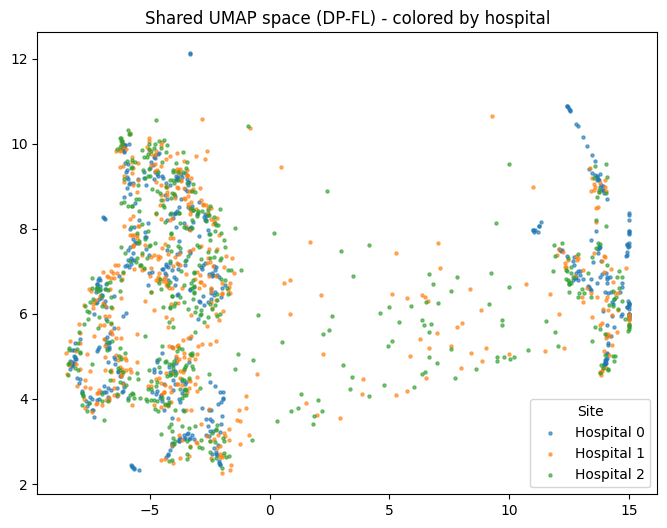

In [8]:
plt.figure(figsize=(8, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i, (proj, y) in enumerate(zip(local_umap, local_labels)):
    plt.scatter(proj[:, 0], proj[:, 1], c=colors[i], s=5, alpha=0.6, label=f'Hospital {i}')
plt.legend(title='Site')
plt.title('Shared UMAP space (DP-FL) - colored by hospital')
plt.savefig('B_dp_perhosp_umap.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 4 — DP federated centroids and radii

Class 0: DP federated centroid = [-3.128  6.097] (n=1075)
Class 1: DP federated centroid = [5.43  7.538] (n=425)
Class 0: DP federated radius (noised max) = 5.55
Class 1: DP federated radius (noised max) = 8.00


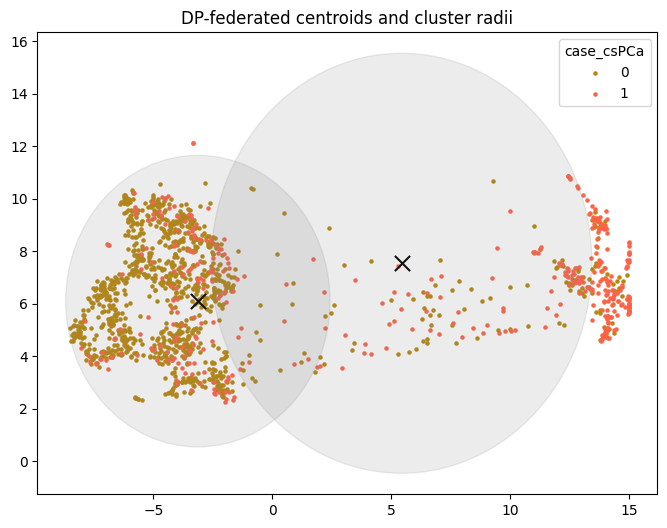

In [9]:
classes = np.unique(np.concatenate(local_labels))
percent_th = 0.9
density_th = 4
umap_range = UMAP_CLIP[1] - UMAP_CLIP[0]

federated_centroids = {}
for c in classes:
    agg_sum, agg_n = np.zeros(2), 0
    for proj, y in zip(local_umap, local_labels):
        m = y == c
        if m.sum() == 0:
            continue
        agg_sum += proj[m].sum(axis=0)
        agg_n += int(m.sum())
    sens_sum2d = math.sqrt(2.0) * umap_range
    eps_c = EPS['centroids'] / len(classes)
    noisy_sum = gaussian_mechanism(agg_sum, sens_sum2d, eps_c, DELTA_PER_QUERY,
                                   accountant, f'centroid sum c{int(c)}', rng)
    federated_centroids[c] = noisy_sum / agg_n
    print(f'Class {int(c)}: DP federated centroid = '
          f'{np.round(federated_centroids[c], 3)} (n={agg_n})')

federated_radii = {}
for c in classes:
    locals_r = []
    for proj, y in zip(local_umap, local_labels):
        m = y == c
        if m.sum() == 0:
            continue
        rad_local = cluster_radius_for_centroid(
            proj[m], federated_centroids[c], density_th, percent_th, n_class=int(m.sum()),
        )
        locals_r.append(min(float(rad_local), RAD_CAP))
    raw_max = max(locals_r)
    eps_r = EPS['radii'] / len(classes)
    radius_sensitivity = 1.0   # one patient changes a cluster-wide radius by at most ~1 unit
    noised = gaussian_mechanism(np.array([raw_max]), radius_sensitivity,
                                eps_r, DELTA_PER_QUERY,
                                accountant, f'radius max c{int(c)}', rng)[0]
    federated_radii[c] = max(1.0, min(float(noised), RAD_CAP))
    print(f'Class {int(c)}: DP federated radius (noised max) = {federated_radii[c]:.2f}')

plt.figure(figsize=(8, 6))
all_proj = np.concatenate(local_umap)
all_y = np.concatenate(local_labels)
plt.scatter(all_proj[all_y == 0, 0], all_proj[all_y == 0, 1],
            c='darkgoldenrod', s=5, label='0')
plt.scatter(all_proj[all_y == 1, 0], all_proj[all_y == 1, 1],
            c='tomato', s=5, label='1')
for c, cent in federated_centroids.items():
    plt.scatter(cent[0], cent[1], c='black', marker='x', s=120)
    plt.gca().add_patch(Circle(cent, federated_radii[c], color='grey', alpha=0.15))
plt.legend(title='case_csPCa')
plt.title('DP-federated centroids and cluster radii')
plt.savefig('B_dp_ref_umap.png', dpi=200, bbox_inches='tight')
plt.show()

## Step 5 — DP federated epsilons (reliability thresholds)

In [10]:
n_neigh = 10
agg_disp_sum = np.zeros(len(FEATURES))
agg_n_disp = 0
for proj, X_i in zip(local_umap, local_features):
    if len(proj) <= n_neigh:
        continue
    Xc = clip(X_i, lo_vec, hi_vec)
    nbrs = NearestNeighbors(n_neighbors=n_neigh, algorithm='auto').fit(proj)
    _, idxs = nbrs.kneighbors(proj)
    for f in range(Xc.shape[1]):
        mean_neigh = np.mean(Xc[idxs, f], axis=1)
        agg_disp_sum[f] += np.sum(np.abs(mean_neigh - Xc[:, f]))
    agg_n_disp += len(proj)

sens_disp = float(np.linalg.norm(hi_vec - lo_vec))
noisy_disp_sum = gaussian_mechanism(
    agg_disp_sum, sens_disp, EPS['epsilons'], DELTA_PER_QUERY,
    accountant, 'epsilons (central)', rng,
)
eps_v = np.maximum(np.round(noisy_disp_sum / agg_n_disp).astype(int), 1)
print('DP federated epsilons (age, psa, pvol):', eps_v.tolist())

DP federated epsilons (age, psa, pvol): [1, 3, 7]


## Step 6 — DP federated min/max ranges

In [11]:
all_mins, all_maxes = [], []
for h in hospitals:
    X = clip(h[FEATURES].to_numpy(), lo_vec, hi_vec)
    all_mins.append(X.min(axis=0))
    all_maxes.append(X.max(axis=0))

agg_min = np.minimum.reduce(all_mins)
agg_max = np.maximum.reduce(all_maxes)

sens_mm = float(np.linalg.norm(hi_vec - lo_vec))
eps_m = EPS['minmax'] / 2  # half for min, half for max
noisy_min = gaussian_mechanism(agg_min, sens_mm, eps_m, DELTA_PER_QUERY,
                               accountant, 'min (central)', rng)
noisy_max = gaussian_mechanism(agg_max, sens_mm, eps_m, DELTA_PER_QUERY,
                               accountant, 'max (central)', rng)

# Clip back to public bounds; ensure min < max even if noise reversed them
global_min = clip(noisy_min, lo_vec, hi_vec)
global_max = clip(noisy_max, lo_vec, hi_vec)
for i in range(len(FEATURES)):
    if global_min[i] >= global_max[i]:
        # Fall back to the public clipping bounds
        global_min[i] = lo_vec[i]
        global_max[i] = hi_vec[i]

minmax_v = [
    [global_min[0], global_max[0]],
    [0.0, 100.0],   # PSA: keep original M-range (public)
    [global_min[2], global_max[2]],
]
print('DP federated min/max:')
for f, (mn, mx) in zip(FEATURES, minmax_v):
    print(f'  {f:<18}  [{mn:.2f}, {mx:.2f}]')

DP federated min/max:
  patient_age         [40.00, 85.00]
  psa                 [0.00, 100.00]
  prostate_volume     [20.00, 150.00]


## Step 7 — Local synthetic generation under the DP-shared rules

In [12]:
sel_reliability = 1
step_v = [1, 0.5, 1]

def local_generation_at_hospital(hosp_features_df, manifold, norm_fn,
                                 federated_centroids, federated_radii,
                                 eps_v, minmax_v, step_v,
                                 sel_reliability, n_neigh):
    X_local = hosp_features_df.to_numpy()
    umap_local = manifold.transform(norm_fn(X_local))
    missing_data = hosp_features_df.copy()
    partially_synth_feature_cluster = pd.DataFrame()

    for index in range(2, -1, -1):
        uncompleted_df = missing_data.copy()
        uncompleted_df.iloc[:, index] = np.nan
        min_value, max_value = minmax_v[index]
        step = step_v[index]
        eps = eps_v[index]
        partially_synth_feature = pd.DataFrame()
        partially_synth_feature_cluster = pd.DataFrame()

        for target_value in np.arange(min_value, max_value + 1, step):
            generated_df = uncompleted_df.copy()
            generated_df.iloc[:, index] = target_value
            generated_df = generated_df.drop_duplicates()
            if generated_df.empty:
                continue

            X_gen_norm = norm_fn(generated_df.to_numpy())
            umap_gen = manifold.transform(X_gen_norm)

            nbrs = NearestNeighbors(
                n_neighbors=min(n_neigh, len(umap_local)), algorithm='auto'
            ).fit(umap_local)
            _, idxs = nbrs.kneighbors(umap_gen)
            mean_neighbor_feat = np.mean(X_local[idxs, index], axis=1)
            feat_dist = np.abs(mean_neighbor_feat - target_value)

            reliab = np.where(feat_dist <= eps, 1.0,
                       np.where(feat_dist <= 2*eps, 0.9,
                       np.where(feat_dist <= 3*eps, 0.8,
                       np.where(feat_dist <= 4*eps, 0.7,
                       np.where(feat_dist <= 5*eps, 0.6,
                       np.where(feat_dist <= 6*eps, 0.5, 0.2))))))
            valid = np.where(reliab == sel_reliability)[0]
            if len(valid) == 0:
                continue

            partial = generated_df.iloc[valid]
            partially_synth_feature = pd.concat(
                [partially_synth_feature, partial], ignore_index=True
            )
            missing_data = partially_synth_feature

            if index == 0:
                dists = np.array([np.linalg.norm(umap_gen - c, axis=1)
                                  for c in federated_centroids.values()])
                closest = np.argmin(dists, axis=0)
                cluster_vec = np.full(len(umap_gen), np.nan)
                ckeys = list(federated_centroids.keys())
                for ii, mind in enumerate(np.min(dists, axis=0)):
                    ck = ckeys[closest[ii]]
                    if mind < federated_radii[ck]:
                        cluster_vec[ii] = float(ck)
                gen_cluster = generated_df.copy()
                gen_cluster['case_csPCa'] = cluster_vec
                partial_cluster = gen_cluster.iloc[valid]
                partially_synth_feature_cluster = pd.concat(
                    [partially_synth_feature_cluster, partial_cluster],
                    ignore_index=True,
                )
                partially_synth_feature_cluster = (
                    partially_synth_feature_cluster.dropna(subset=['case_csPCa'])
                )
    return partially_synth_feature_cluster

per_site_synth = []
for i, h in enumerate(hospitals):
    print(f'Hospital {i}: generating ...')
    synth_i = local_generation_at_hospital(
        hosp_features_df=h[FEATURES],
        manifold=manifold,
        norm_fn=federated_standardize,
        federated_centroids=federated_centroids,
        federated_radii=federated_radii,
        eps_v=eps_v,
        minmax_v=minmax_v,
        step_v=step_v,
        sel_reliability=sel_reliability,
        n_neigh=n_neigh,
    )
    print(f'  -> {len(synth_i)} validated synthetic rows')
    per_site_synth.append(synth_i)

Hospital 0: generating ...
  -> 74476 validated synthetic rows
Hospital 1: generating ...
  -> 74551 validated synthetic rows
Hospital 2: generating ...
  -> 69785 validated synthetic rows


## Step 8 — Pool synthetic outputs and verify privacy budget

In [13]:
fully_synth = pd.concat(per_site_synth, ignore_index=True)
print('Total DP-FL synthetic rows:', len(fully_synth))
if len(fully_synth) > 0:
    print('csPCa+ rate in pooled synthetic:',
          fully_synth['case_csPCa'].mean().round(3))
fully_synth.to_csv('fully_synthetic_data_federated_DP.csv', index=False)
print('Saved fully_synthetic_data_federated_DP.csv')

Total DP-FL synthetic rows: 218812
csPCa+ rate in pooled synthetic: 0.254
Saved fully_synthetic_data_federated_DP.csv


Visualize the final DP-FL synthetic dataset

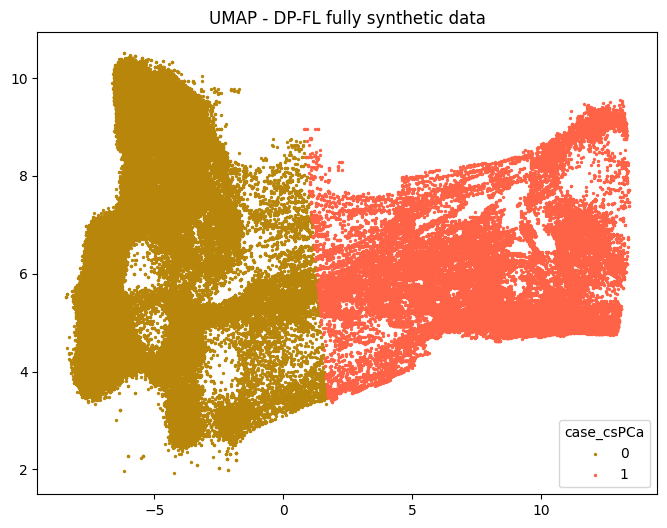

In [14]:
if len(fully_synth) > 0:
    X_fully = fully_synth.drop(['case_csPCa'], axis=1)
    y_fully = fully_synth['case_csPCa'].values.flatten()
    X_fully_norm = federated_standardize(X_fully.to_numpy())
    umap_fully = manifold.transform(X_fully_norm)

    plt.figure(figsize=(8, 6))
    class_0_idx = y_fully == 0.0
    plt.scatter(umap_fully[class_0_idx, 0], umap_fully[class_0_idx, 1],
                c='darkgoldenrod', label='0', s=2)
    class_1_idx = y_fully == 1.0
    plt.scatter(umap_fully[class_1_idx, 0], umap_fully[class_1_idx, 1],
                c='tomato', label='1', s=2)
    plt.legend(title='case_csPCa')
    plt.title('UMAP - DP-FL fully synthetic data')
    plt.savefig('B_dp_synth_combined.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('No synthetic data to plot.')

### Fidelity (KS) and Utility (TSTR) evaluation

In [15]:
from scipy.stats import ks_2samp
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split

real_full = pd.read_csv('marksheet_minimal.csv').drop(['psad', 'psad_computed'], axis=1)
real_full = pd.DataFrame(KNNImputer(n_neighbors=10).fit_transform(real_full),
                         columns=real_full.columns)

if len(fully_synth) > 0:
    # Fidelity
    ks_results = {}
    for feature in FEATURES:
        stat, _ = ks_2samp(real_full[feature], fully_synth[feature])
        ks_results[feature] = stat
    print('\nKS distance per feature:')
    for f, v in ks_results.items():
        print(f'  {f}: {v:.4f}')
    print(f'Mean KS distance: {sum(ks_results.values()) / len(ks_results):.4f}')

    # Utility (TSTR)
    X_real = real_full.drop('case_csPCa', axis=1)
    y_real = real_full['case_csPCa']
    _, X_test_real, _, y_test_real = train_test_split(
        X_real, y_real, test_size=0.3, stratify=y_real, random_state=42
    )

    X_synth = fully_synth.drop('case_csPCa', axis=1)
    y_synth = fully_synth['case_csPCa']

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_synth, y_synth)
    y_pred = clf.predict(X_test_real)
    y_proba = clf.predict_proba(X_test_real)[:, 1]

    print()
    print(f'TSTR AUC:      {roc_auc_score(y_test_real, y_proba):.4f}')
    print(f'TSTR F1:       {f1_score(y_test_real, y_pred):.4f}')
    print(f'TSTR Accuracy: {accuracy_score(y_test_real, y_pred):.4f}')
    print(f'\nTotal DP-FL synthetic samples: {len(fully_synth)}')

    print('\nPer-hospital synthetic counts:')
    for i, sub in enumerate(per_site_synth):
        print(f'  Hospital {i}: {len(sub)} validated samples')
else:
    print('\nNo synthetic samples generated - check DP configuration.')

print()
accountant.report()


KS distance per feature:
  patient_age: 0.1145
  psa: 0.2706
  prostate_volume: 0.1815
Mean KS distance: 0.1889

TSTR AUC:      0.7215
TSTR F1:       0.5625
TSTR Accuracy: 0.7511

Total DP-FL synthetic samples: 218812

Per-hospital synthetic counts:
  Hospital 0: 74476 validated samples
  Hospital 1: 74551 validated samples
  Hospital 2: 69785 validated samples

Privacy budget: epsilon_total = 10.0, delta_total = 1e-05
Spent: epsilon = 10.0000, delta = 1.00e-05
------------------------------------------------------------------------------
query                                eps      delta       Delta       sigma
std_sum (central)                  1.000    1.1e-06     146.373    772.6847
std_sum_sq (central)               3.000    1.1e-06   23763.430  41814.7757
centroid sum c0                    1.000    1.1e-06      42.426    223.9640
centroid sum c1                    1.000    1.1e-06      42.426    223.9640
radius max c0                      0.750    1.1e-06       1.000      7.038